<a href="https://colab.research.google.com/github/singhayushi14470-collab/Machine_Learning_1/blob/main/woking_with_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# create the random data sample
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1=np.array([0,0,0])
co_mat1=np.array(([1,0,0],[0,1,0],[0,0,1]))
class1_sample=np.random.multivariate_normal(mu_vec1,co_mat1,20)


df=pd.DataFrame(class1_sample,columns=["f1","f2","f3"])
df["target"]=1

mu_vec2=np.array([1,1,1])
co_mat2=np.array(([1,0,0],[0,1,0],[0,0,1]))
class2_sample=np.random.multivariate_normal(mu_vec2,co_mat2,20)

df1=pd.DataFrame(class2_sample,columns=["f1","f2","f3"])

df1["target"]=0

df.head()
df1.head()

,f1,f2,f3,target
0,1.250737,0.186384,1.703624,0
1,0.731858,0.517441,2.244610,0
2,1.676860,4.187503,-0.080565,0
3,1.010229,1.437830,2.327788,0
4,0.748855,2.593111,1.170818,0


In [24]:
import plotly.express as px
#y_train_trf=y_train.astype(str)
fig=px.scatter_3d(df,x=df["f1"],y=df["f2"],z=df["f3"],color=df["target"].astype("str"))
fig.update_traces(marker=dict(size=12,line=dict(width=2,color="DarkSlateGrey")),selector=dict(mode="markers"))
fig.show()



In [25]:
# step apply standard scaling
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()

df.iloc[:,0:3]=scale.fit_transform(df.iloc[:,0:3])

In [26]:
#step2 find covariace variance
cov_mat=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print("covariance_matrix:\n",cov_mat)


covariance_matrix:
 [[ 1.05263158  0.20397591 -0.28888004]
 [ 0.20397591  1.05263158  0.10956124]
 [-0.28888004  0.10956124  1.05263158]]


In [27]:
#step3 finding EVactor and Evalues
ei_val,ei_vect=np.linalg.eig(cov_mat)

In [28]:
ei_val

array([0.64212617, 1.36120658, 1.15456198])

In [29]:
ei_vect

array([[-0.65172443,  0.74834128,  0.12345283],
       [ 0.48046517,  0.28140349,  0.8306415 ],
       [-0.58686326, -0.60066414,  0.54294945]])

In [30]:
%pylab inline
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch

Populating the interactive namespace from numpy and matplotlib


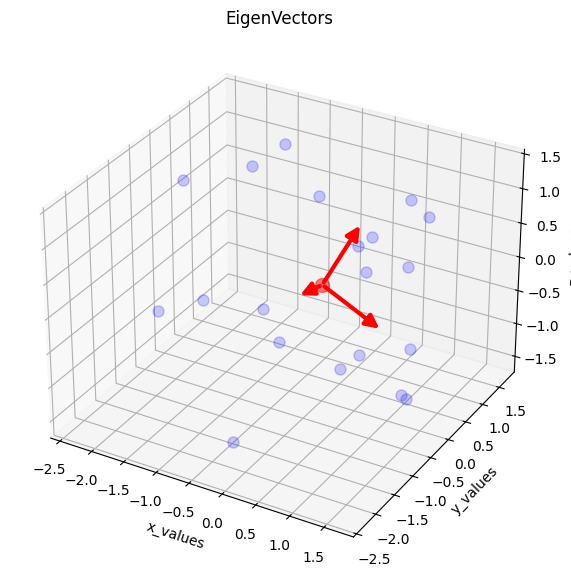

In [33]:
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
       return np.min(self._verts3d[2])

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['f1'], df['f2'], df['f3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['f1'].mean()], [df['f2'].mean()], [df['f3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in ei_vect.T:
    a = Arrow3D([df['f1'].mean(), v[0]], [df['f2'].mean(), v[1]], [df['f3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('EigenVectors')

plt.show()

In [34]:
pc=ei_vect[0:2]
pc

array([[-0.65172443,  0.74834128,  0.12345283],
       [ 0.48046517,  0.28140349,  0.8306415 ]])

In [38]:
transform_df=np.dot(df.iloc[:,0:3],pc.T)
new_df=pd.DataFrame(transform_df,columns=["pc1","pc2"])
new_df["target"]=df["target"].values
new_df.head()

,pc1,pc2,target
0,-0.304909,-0.545559,1
1,0.238477,-0.429512,1
2,-1.078773,-2.044435,1
3,-1.135779,1.289053,1
4,-0.107685,-0.957342,1


In [39]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['pc1'],
                 y=new_df['pc2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

